In [71]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import math

In [8]:
x=sp.Symbol('x')

def func():
    return sp.sin(x)*sp.exp(-x**2*0.05)

def dx():
    fun=func()
    return sp.diff(fun)

def convert():
    loss=func()
    loss_dx=dx()
    loss=sp.lambdify(x,loss,"numpy")
    ldx=sp.lambdify(x,loss_dx,"numpy")
    return loss,ldx

loss,ldx=convert()

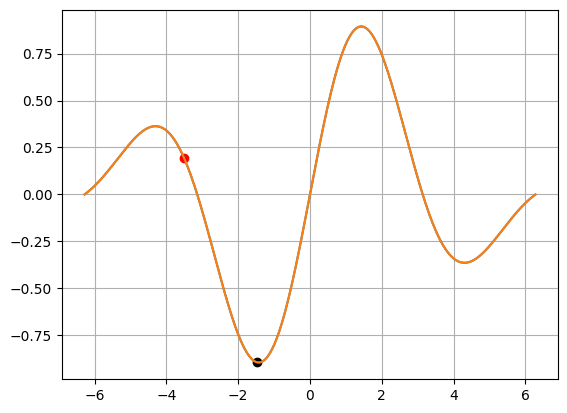

-1.4792184329769449


In [104]:
points=np.linspace(-2*np.pi,2*np.pi,400)

xx=np.random.choice(points)

y=loss(points)
fig,ax=plt.subplots()
ax.plot(points,y)
ax.scatter(xx,loss(xx),c='red')

te=500
lr=0.01

for i in range(te):
    xx=xx-lr*ldx(xx)

ax.plot(points,y)
ax.scatter(xx,loss(xx),c='Black')


plt.grid(True)
plt.show()
print(xx)

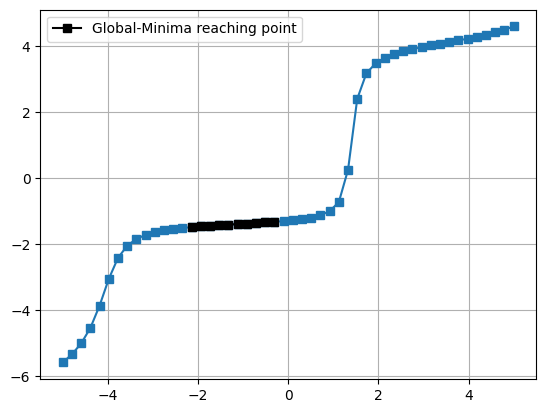

The probability to find Global minima from a random starting point for 250 traning epochs and for this curve is 0.2


In [106]:
#Lets play with starting Location.
#EXP-A

start_location=np.linspace(-5,5,50)
final_location=np.zeros(len(start_location))
perfect_value=[]
perfect_solution=[]

tr=250
lr=0.01


for index,i in enumerate(start_location):
    x=i
    for j in range(tr):
        x=x-lr*ldx(x)
    final_location[index]=x
    if math.isclose(-1.42,x,abs_tol=0.1):# if picking another curve u need to insert global minimum instead of -1.42
        perfect_value.append(i)
        perfect_solution.append(x)
        

fig,ax=plt.subplots()

ax.plot(start_location,final_location,'s-')
ax.plot(perfect_value,perfect_solution,'s-',c='Black',label='Global-Minima reaching point')

plt.grid(True)
plt.legend()
plt.show()
# print(start_location)
# print(final_location)
# print(perfect_value)
# print(perfect_solution)
print(f"The probability to find Global minima from a random starting point for 250 traning epochs and for this curve is {len(perfect_value)/len(start_location)}")

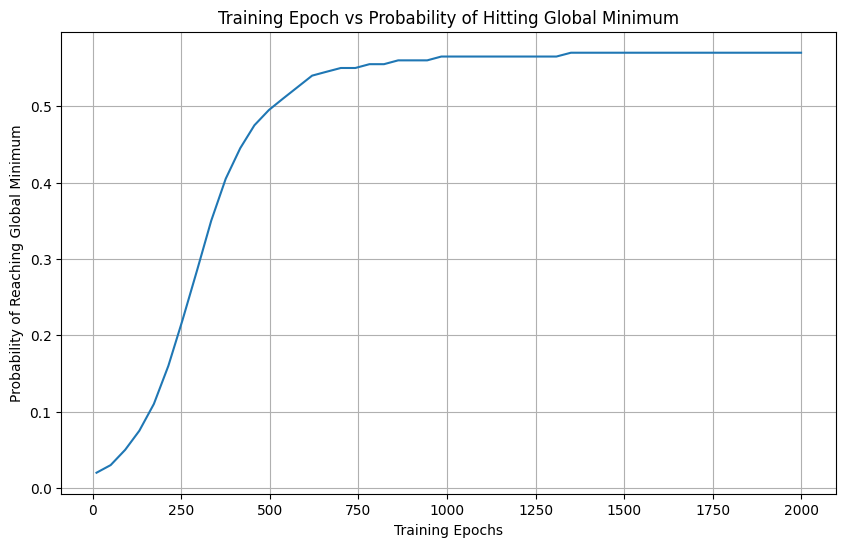

In [101]:
#lets improve the traning epochs to find the probability.
#It can take some time get the result 3 nested-loops
#EXP-B

start_location=np.linspace(-5, 5, 200)
training_epochs=np.linspace(10, 2000, 50, dtype=int)
lr = 0.01

probabilities = []

global_min = -1.42

for te in training_epochs:
    success_count = 0

    for start in start_location:
        x = start
        
        for _ in range(te):
            x = x - lr * ldx(x)
        if math.isclose(x, global_min, abs_tol=0.1):
            success_count += 1
    probability = success_count / len(start_location)
    probabilities.append(probability)

plt.figure(figsize=(10,6))
plt.plot(training_epochs, probabilities)
plt.xlabel("Training Epochs")
plt.ylabel("Probability of Reaching Global Minimum")
plt.title("Training Epoch vs Probability of Hitting Global Minimum")
plt.grid(True)

plt.show()

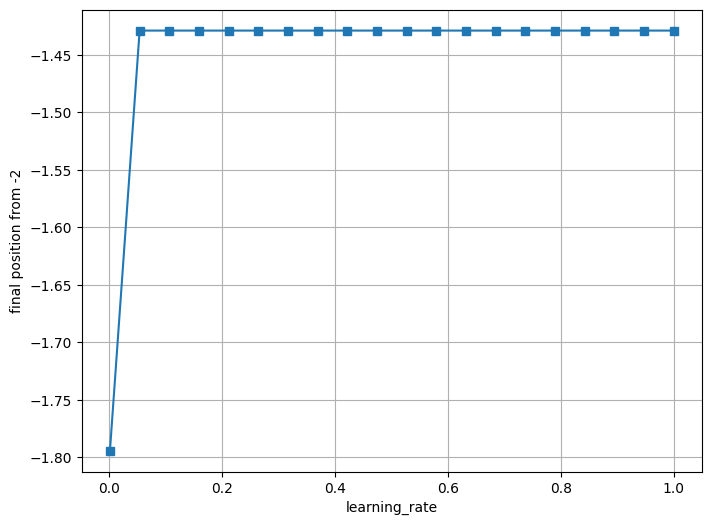

[0.001      0.05357895 0.10615789 0.15873684 0.21131579 0.26389474
 0.31647368 0.36905263 0.42163158 0.47421053 0.52678947 0.57936842
 0.63194737 0.68452632 0.73710526 0.78968421 0.84226316 0.89484211
 0.94742105 1.        ]
[-1.79409023 -1.42887001 -1.42887001 -1.42887001 -1.42887001 -1.42887001
 -1.42887001 -1.42887001 -1.42887001 -1.42887001 -1.42887001 -1.42887001
 -1.42887001 -1.42887001 -1.42887001 -1.42887001 -1.42887001 -1.42887001
 -1.42887001 -1.42887001]


In [111]:
#Exp-C (learning rate increase vs chnaces of hitting the gloabal minimum)

points=np.linspace(-2*np.pi,2*np.pi,400)
start_point=-2

te=500

#NOTE-> -2 as initial value, with 500 traning epochs is guarantee to hit global minima now everything depends upon learning rate 

lr=np.linspace(0.001,1,20)
final_point=np.zeros(len(lr))

for index,i in enumerate(lr):
    x=start_point
    for j in range(te):
        x=x-i*ldx(x)
    final_point[index]=x

plt.figure(figsize=(8,6))
plt.plot(lr,final_point,'s-')
plt.xlabel("learning_rate")
plt.ylabel("final position from -2")
plt.grid(True)

plt.show()
print(lr)
print(final_point)

# The Conclusion of 3 exp:

### EXP A:- The initial-point matter and for low training epochs(if picked) and learning rate and not all points and lead us to global minima it depends upon nature of curve 
### Exp B:- Finding the optimal training epoch is also needed as we seen, training more does'nt mean more better solution as 750 to 2000 training epochs leads us to same solution, So why pick higher and increase Time to train.
### Exp C:- Picking a optimial learning rate also matters, learning rate is generally kept 0.01 
### In Exp C try keep the range (0.001,10,20) and then see the difference in result

### So for a successfull gradient-descent we have to have optimal (training epochs, learning rate) and a good starting point to find global minima 

#### Future exp-D training epoch+learning rate variables to find the final_point and plot.